## 1. Import the necessary libraries.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 2. Load the we_fn_use_c_marketing_customer_value_analysis.csv into the variable customer_df

In [2]:
customer_df = pd.read_csv('we_fn_use_c_marketing_customer_value_analysis.csv')
customer_df

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,LA72316,California,23405.987980,No,Basic,Bachelor,2/10/11,Employed,M,71941,...,89,0,2,Personal Auto,Personal L1,Offer2,Web,198.234764,Four-Door Car,Medsize
9130,PK87824,California,3096.511217,Yes,Extended,College,2/12/11,Employed,F,21604,...,28,0,1,Corporate Auto,Corporate L3,Offer1,Branch,379.200000,Four-Door Car,Medsize
9131,TD14365,California,8163.890428,No,Extended,Bachelor,2/6/11,Unemployed,M,0,...,37,3,2,Corporate Auto,Corporate L2,Offer1,Branch,790.784983,Four-Door Car,Medsize
9132,UP19263,California,7524.442436,No,Extended,College,2/3/11,Employed,M,21941,...,3,0,3,Personal Auto,Personal L2,Offer3,Branch,691.200000,Four-Door Car,Large


## 3. First look at its main features (head, shape, info).

In [3]:
customer_df. head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [4]:
customer_df.shape

(9134, 24)

In [5]:
customer_df.info

<bound method DataFrame.info of      Customer       State  Customer Lifetime Value Response  Coverage  \
0     BU79786  Washington              2763.519279       No     Basic   
1     QZ44356     Arizona              6979.535903       No  Extended   
2     AI49188      Nevada             12887.431650       No   Premium   
3     WW63253  California              7645.861827       No     Basic   
4     HB64268  Washington              2813.692575       No     Basic   
...       ...         ...                      ...      ...       ...   
9129  LA72316  California             23405.987980       No     Basic   
9130  PK87824  California              3096.511217      Yes  Extended   
9131  TD14365  California              8163.890428       No  Extended   
9132  UP19263  California              7524.442436       No  Extended   
9133  Y167826  California              2611.836866       No  Extended   

     Education Effective To Date EmploymentStatus Gender  Income  ...  \
0     Bachelor    

## 4. Rename the columns so they follow the PE8 (snake case) (lower_case_with_underscores)

In [6]:
customer_df = customer_df.rename(columns={'EmploymentStatus': 'Employment Status'})
customer_df.columns = [colname.lower().replace(' ','_') for colname in customer_df.columns]
display(customer_df.columns)

Index(['customer', 'state', 'customer_lifetime_value', 'response', 'coverage',
       'education', 'effective_to_date', 'employment_status', 'gender',
       'income', 'location_code', 'marital_status', 'monthly_premium_auto',
       'months_since_last_claim', 'months_since_policy_inception',
       'number_of_open_complaints', 'number_of_policies', 'policy_type',
       'policy', 'renew_offer_type', 'sales_channel', 'total_claim_amount',
       'vehicle_class', 'vehicle_size'],
      dtype='object')

## 5. Change effective to date column to datetime format.

In [7]:
customer_df['effective_to_date'] = pd.to_datetime(customer_df['effective_to_date'], errors='coerce')
customer_df.dtypes

customer                                 object
state                                    object
customer_lifetime_value                 float64
response                                 object
coverage                                 object
education                                object
effective_to_date                datetime64[ns]
employment_status                        object
gender                                   object
income                                    int64
location_code                            object
marital_status                           object
monthly_premium_auto                      int64
months_since_last_claim                   int64
months_since_policy_inception             int64
number_of_open_complaints                 int64
number_of_policies                        int64
policy_type                              object
policy                                   object
renew_offer_type                         object
sales_channel                           

## 6. Define a function that differentiates between continuous and discrete variables.
### Hint: The number of unique values might be useful. Store continuous data into a continuous_df variable and do the same for discrete_df

In [8]:
customer_df_num = customer_df._get_numeric_data()
customer_df_num

,customer_lifetime_value,income,monthly_premium_auto,months_since_last_claim,months_since_policy_inception,number_of_open_complaints,number_of_policies,total_claim_amount
0,2763.519279,56274,69,32,5,0,1,384.811147
1,6979.535903,0,94,13,42,0,8,1131.464935
2,12887.431650,48767,108,18,38,0,2,566.472247
3,7645.861827,0,106,18,65,0,7,529.881344
4,2813.692575,43836,73,12,44,0,1,138.130879
...,...,...,...,...,...,...,...,...
9129,23405.987980,71941,73,18,89,0,2,198.234764
9130,3096.511217,21604,79,14,28,0,1,379.200000
9131,8163.890428,0,85,9,37,3,2,790.784983
9132,7524.442436,21941,96,34,3,0,3,691.200000


In [9]:
# Let's look at the number of unique values for each numerical column
for col in customer_df_num.columns:
    print(col, 'has', len(customer_df_num[col].unique()), 'unique values')
    display(customer_df_num[col].unique())

customer_lifetime_value has 8041 unique values


array([ 2763.519279,  6979.535903, 12887.43165 , ...,  8163.890428,
        7524.442436,  2611.836866])

income has 5694 unique values


array([56274,     0, 48767, ..., 66367, 71941, 21941], dtype=int64)

monthly_premium_auto has 202 unique values


...

array([0, 2, 1, 3, 5, 4], dtype=int64)

number_of_policies has 9 unique values


array([1, 8, 2, 7, 9, 4, 3, 6, 5], dtype=int64)

total_claim_amount has 5106 unique values


array([ 384.811147, 1131.464935,  566.472247, ...,  541.282007,
        198.234764,  790.784983])

We see we have that out of the 8 columns, 3 have more than 5.000 unique values, whereas the other ones have a much lower amount. 
Those are definitely continuous variable, even though the income column only shows integer figures. Those are probably just rounded amounts that can be considered continuous. Same happens for the monthly premium, even if the number of unique values is much lower (202).
The 4 other columns contain variables that count elements and are discrete.

To use a function, I'll set a 200 unique values limit to split the two types of variables.

In [10]:
def column_category(colname):
    if len(colname.unique()) >= 200:    # checks for each column the number of unique values
        return "continuous"       # returns continuous if the column has more than 1.000 unique values
    else:
        return "discrete"

In [11]:
continuous_columns = []
discrete_columns = []

for colname in customer_df_num.columns:
    if column_category(customer_df_num[colname]) == "continuous":
        continuous_columns.append(colname)
    else:
        discrete_columns.append(colname)

In [12]:
continuous_df = customer_df_num[continuous_columns].copy()
continuous_df

,customer_lifetime_value,income,monthly_premium_auto,total_claim_amount
0,2763.519279,56274,69,384.811147
1,6979.535903,0,94,1131.464935
2,12887.431650,48767,108,566.472247
3,7645.861827,0,106,529.881344
4,2813.692575,43836,73,138.130879
...,...,...,...,...
9129,23405.987980,71941,73,198.234764
9130,3096.511217,21604,79,379.200000
9131,8163.890428,0,85,790.784983
9132,7524.442436,21941,96,691.200000


In [13]:
discrete_df = customer_df_num[discrete_columns].copy()
discrete_df

,months_since_last_claim,months_since_policy_inception,number_of_open_complaints,number_of_policies
0,32,5,0,1
1,13,42,0,8
2,18,38,0,2
3,18,65,0,7
4,12,44,0,1
...,...,...,...,...
9129,18,89,0,2
9130,14,28,0,1
9131,9,37,3,2
9132,34,3,0,3


## 7. Plot a correlation matrix, comment what you see.

In [14]:
corr_matrix = customer_df.corr()
corr_matrix

,customer_lifetime_value,income,monthly_premium_auto,months_since_last_claim,months_since_policy_inception,number_of_open_complaints,number_of_policies,total_claim_amount
customer_lifetime_value,1.000000,0.024366,0.396262,0.011517,0.009418,-0.036343,0.021955,0.226451
income,0.024366,1.000000,-0.016665,-0.026715,-0.000875,0.006408,-0.008656,-0.355254
monthly_premium_auto,0.396262,-0.016665,1.000000,0.005026,0.020257,-0.013122,-0.011233,0.632017
months_since_last_claim,0.011517,-0.026715,0.005026,1.000000,-0.042959,0.005354,0.009136,0.007563
months_since_policy_inception,0.009418,-0.000875,0.020257,-0.042959,1.000000,-0.001158,-0.013333,0.003335
number_of_open_complaints,-0.036343,0.006408,-0.013122,0.005354,-0.001158,1.000000,0.001498,-0.014241
number_of_policies,0.021955,-0.008656,-0.011233,0.009136,-0.013333,0.001498,1.000000,-0.002354
total_claim_amount,0.226451,-0.355254,0.632017,0.007563,0.003335,-0.014241,-0.002354,1.000000


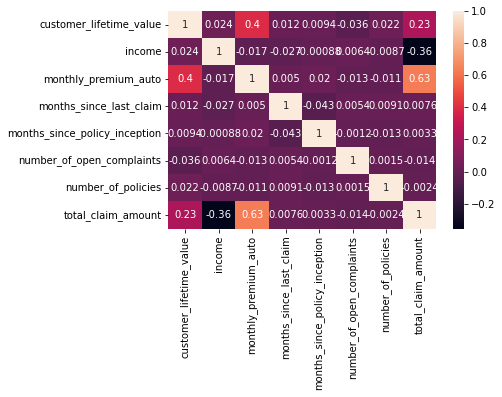

In [15]:
sns.heatmap(corr_matrix, annot=True)
plt.show()

From the correlation matrix or heatmap, we see that none of the columns is strongly correlated to another.
The strongest correlations are between monthly premium and total claim amount (0.63) and between customer lifetime and monthly premium auto. In both cases, the correlation seems pretty logical, but they are not strong enough to justify dropping one of the columns.

## 8. Create a function to plot every discrete variable. Do the same with the continuous variables
### Be Careful, you may need to change the plot type to one better suited for continuous data!

In [16]:
def discrete_plot(df):
    for var in df.columns:
        sns.displot(df[var])
        plt.show()

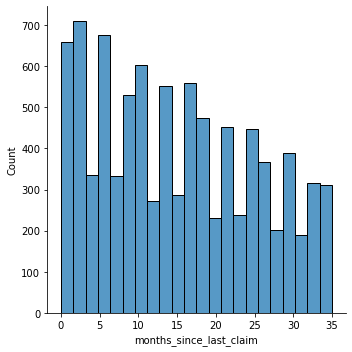

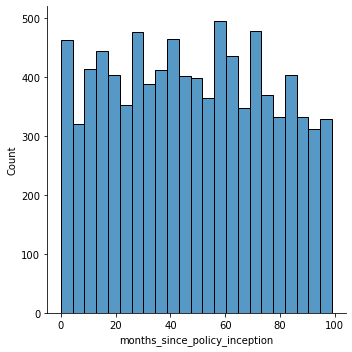

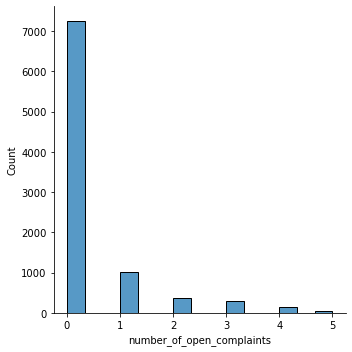

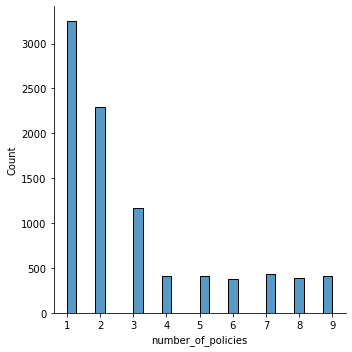

In [17]:
discrete_plot(discrete_df)

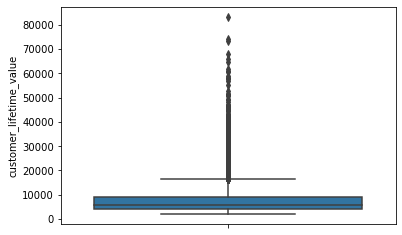

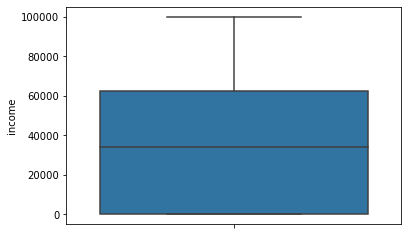

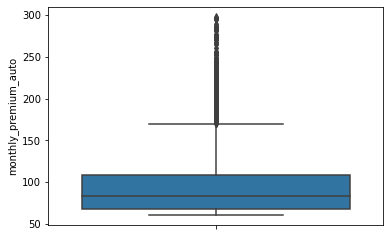

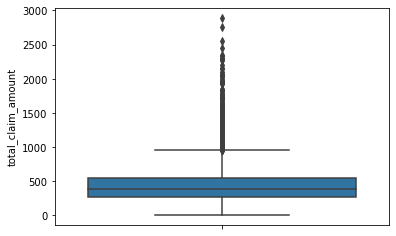

In [18]:
# for the continuous variables, I will apply a box plot
def continuous_box_plot(df):
    for vars_ in df.columns:
        sns.boxplot(y=df[vars_])
        plt.show()
        
continuous_box_plot(continuous_df)

## 9-10-11. Comment what you can see in the plots.
## Look for outliers in the continuous variables. If you find some, what will you do with them ?

### Discrete variables

#### Months since last claim
The distribution is more flat here. The range is going from 1 to 36 months. To reduce the number of variations, I'll change it to years, from 1 to 3. This way, the feature remains numerical

In [19]:
def clean_month_since_claim(x):
    if x < 12:
        return 0
    elif x < 24:
        return 1
    else:
        return 2

customer_df['years_since_last_claim'] = customer_df['months_since_last_claim'].apply(clean_month_since_claim)
customer_df['years_since_last_claim'].value_counts()

0    3846
1    3066
2    2222
Name: years_since_last_claim, dtype: int64

#### Months since policy inception
Same obeservation as for the months since last claims, the distribution is flat. This time, it ranges from 0 to roughly 100 months, which I will cut in segments of 2 years. I will use numerical identifiers for the categories, so that the variable remains numerical.

In [20]:
def clean_month_since_inception(x):
    if x < 24:
        return 2
    elif x < 48:
        return 4
    elif x < 72:
        return 6
    else:
        return 8

customer_df['years_since_policy_inception'] = customer_df['months_since_policy_inception'].apply(clean_month_since_inception)
customer_df['years_since_policy_inception'].value_counts()

6    2329
4    2314
8    2266
2    2225
Name: years_since_policy_inception, dtype: int64

#### Number of open complaints
We see  that a huge majority of the contracts does not have any open complaint. The number of contracts with open complaints is very low for each of the other amounts (1 to 5 maximum). I will transform this column to only keep the information about the fact there is one or more complaint currently open

In [21]:
customer_df['open_complaints'] = np.where(customer_df['number_of_open_complaints'] == 0, False, True)
customer_df['open_complaints'].value_counts()

False    7252
True     1882
Name: open_complaints, dtype: int64

#### Number of policies
Same story here, we have a great majority of the contracts having 1, 2 or 3 policies. The amounts greater than 3 (4 to 9) have more or less the same population of around 500.
To avoid overweighting those contracts with a high number of policies if we regroup them all, I will create 2 sub categories to regroup the contracts having 4 to 6 and those having 7 to 9 policies

In [22]:
def clean_policies(x):
    if x <= 3:
        return x
    elif x<= 6:
        return '4-6'
    else:
        return '> 6'

customer_df['number_of_policies'] = customer_df['number_of_policies'].apply(clean_policies)
customer_df['number_of_policies'].value_counts()

1      3251
2      2294
> 6    1233
4-6    1188
3      1168
Name: number_of_policies, dtype: int64

## Continuous variables

In [23]:
continuous_df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_lifetime_value,9134.0,8004.940475,6870.967608,1898.007675,3994.251794,5780.182197,8962.167041,83325.381190
income,9134.0,37657.380009,30379.904734,0.000000,0.000000,33889.500000,62320.000000,99981.000000
monthly_premium_auto,9134.0,93.219291,34.407967,61.000000,68.000000,83.000000,109.000000,298.000000
total_claim_amount,9134.0,434.088794,290.500092,0.099007,272.258244,383.945434,547.514839,2893.239678


#### Customer lifetime value
The lifetime variable shows a wide range of values, going from roughly 2000 to 85000.
The boxplot shows that this variable have some outliers in the highest values, but there seem to be lots of them, so dropping them might not be the best solution.
We furthermore do not know how this value is expressed. What can an average lifetime of 8005 mean ? That makes us difficult to understand if the outliers are errors or just actually "older" customers.

In [24]:
iqr_lifetime = np.percentile(customer_df['customer_lifetime_value'],75) - np.percentile(customer_df['customer_lifetime_value'],25)
upper_limit_lifetime = np.percentile(customer_df['customer_lifetime_value'],75) + 1.5*iqr_lifetime
print(upper_limit_lifetime)
extraordinary_points_lifetime = customer_df[customer_df['customer_lifetime_value'] > upper_limit_lifetime]
print(len(extraordinary_points_lifetime))

16414.039911750002
817


Droping the outliers would thus mean "losing" 817 rows out of 9134. That is quite a lot od data to lose.

#### Income
Income range from 0 to almost 100000. This is a wide range but the plot for this variable does not show outliers.
However, the data quality issue relies for me more in the fact that we see that at least the full first quartile is made of customers with 0 income. I guess that this is not possible and shows missing data.

In [25]:
customer_df[customer_df['income']==0]['employment_status'].value_counts()

Unemployed    2317
Name: employment_status, dtype: int64

We thus have 2317 contracts showing no income at all but who are customers that are unemployed.
This is 25% of the data and seems like an incredibly huge part of the customer portfolio but I make the assumption for now that this is not a mistake and will keep the rows as such.

But we also saw that the correlation between income and other elements is low, so binning the data would not lead to a significant loss of data.

In [26]:
# Let's first see an automatic binning by panda.: I apply numerical labels, so that the data remains numerical
income_labels = [1, 2, 3, 4]
customer_df['income_category'] = pd.cut(customer_df['income'],4,labels=income_labels)
customer_df[['income','income_category']].head(20)

,income,income_category
0,56274,3
1,0,1
2,48767,2
3,0,1
4,43836,2
5,62902,3
6,55350,3
7,0,1
8,14072,1
9,28812,2


In [27]:
customer_df['income_category'].value_counts()

1    3529
2    2333
3    1925
4    1347
Name: income_category, dtype: int64

In [28]:
# Let's now apply a binning that I choose myself: I apply numerical labels, so that the data remains numerical and I 
# start with 0 as my lowest bin is for customers with no income.
income_labels_2 = [0, 1, 2, 3]
customer_df['income_category_userdef'] = pd.cut(customer_df['income'],[-1,0,35000,65000,100000],labels=income_labels_2)
customer_df[['income','income_category_userdef']].head(20)

,income,income_category_userdef
0,56274,2
1,0,0
2,48767,2
3,0,0
4,43836,2
5,62902,2
6,55350,2
7,0,0
8,14072,1
9,28812,1


In [29]:
customer_df['income_category_userdef'].value_counts()

2    2403
1    2344
0    2317
3    2070
Name: income_category_userdef, dtype: int64

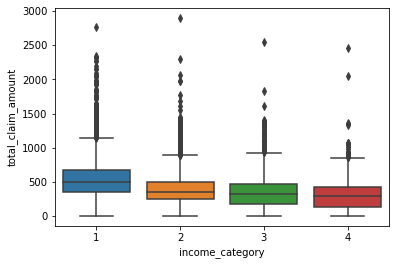

In [30]:
sns.boxplot(x="income_category", y=customer_df.total_claim_amount, data=customer_df)
plt.show()

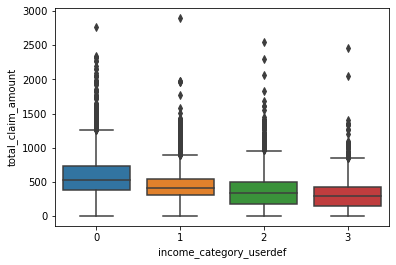

In [31]:
sns.boxplot(x="income_category_userdef", y=customer_df.total_claim_amount, data=customer_df)
plt.show()

The data in both charts are quite similar, but I will keep my binning method as the beans have similar population sizes.

In [32]:
customer_df = customer_df.drop(['income_category'], axis = 1)

#### Monthly Premium Auto
We see that 75% of the values are below 120€ but the range tops up at around 300€, which does seem unconsistant : expensive cars or bad driving history can explain higher premium amounts.
We have seen the correlations were low, so binning this data will probably not make us lose any data.

In [33]:
premium_labels = [1, 2, 3, 4]
customer_df['premium_category'] = pd.cut(customer_df['monthly_premium_auto'],4,labels = premium_labels)
customer_df[['monthly_premium_auto','premium_category']].head(20)

,monthly_premium_auto,premium_category
0,69,1
1,94,1
2,108,1
3,106,1
4,73,1
5,69,1
6,67,1
7,101,1
8,71,1
9,93,1


In [34]:
customer_df['premium_category'].value_counts()

1    7916
2     816
3     325
4      77
Name: premium_category, dtype: int64

The bins are completely imbalanced in term of size. I'll try to balance it with self defined bins and only use three bins.

In [35]:
premium_labels_2 = [1, 2, 3]
customer_df['premium_category_userdef'] = pd.cut(customer_df['monthly_premium_auto'],[0,70,100,300],labels=premium_labels_2)
customer_df['premium_category_userdef'].value_counts()

2    3156
3    3144
1    2834
Name: premium_category_userdef, dtype: int64

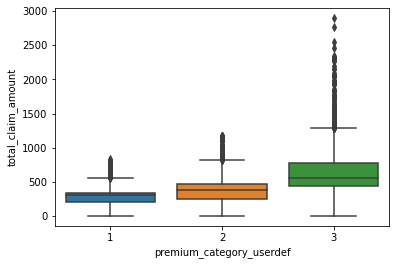

In [36]:
sns.boxplot(x="premium_category_userdef", y=customer_df.total_claim_amount, data=customer_df)
plt.show()

I'll keep my binning, which shows more or less equally sized bins that have interestingly different values for the target.

#### Total claim amount
This is the target. We have lots of outliers in this column, but they are realistic amounts, as a car crash can be quite expensive to repair, or the car itself can be total loss.
Being able to predict thos very expensive claims can be part of the model, so I will keep all the data.

## 12. Check all columns for NaN values. Decide what (if anything) you will need to do with them

In [37]:
customer_df.isna().sum()

customer                         0
state                            0
customer_lifetime_value          0
response                         0
coverage                         0
education                        0
effective_to_date                0
employment_status                0
gender                           0
income                           0
location_code                    0
marital_status                   0
monthly_premium_auto             0
months_since_last_claim          0
months_since_policy_inception    0
number_of_open_complaints        0
number_of_policies               0
policy_type                      0
policy                           0
renew_offer_type                 0
sales_channel                    0
total_claim_amount               0
vehicle_class                    0
vehicle_size                     0
years_since_last_claim           0
years_since_policy_inception     0
open_complaints                  0
income_category_userdef          0
premium_category    

In [38]:
customer_df.isnull().sum()

customer                         0
state                            0
customer_lifetime_value          0
response                         0
coverage                         0
education                        0
effective_to_date                0
employment_status                0
gender                           0
income                           0
location_code                    0
marital_status                   0
monthly_premium_auto             0
months_since_last_claim          0
months_since_policy_inception    0
number_of_open_complaints        0
number_of_policies               0
policy_type                      0
policy                           0
renew_offer_type                 0
sales_channel                    0
total_claim_amount               0
vehicle_class                    0
vehicle_size                     0
years_since_last_claim           0
years_since_policy_inception     0
open_complaints                  0
income_category_userdef          0
premium_category    

There is no NaN nor NULL values in this dataset.

#       LAB 4-2 - CLEANING OF CATEGORICAL DATA

## 1. Import the necessary libraries if you are starting a new notebook. Using the same data as the previous lab: we_fn_use_c_marketing_customer_value_analysis.csv

already done in part 1

## 2. Find all of the categorical data. Save it in a categorical_df variable.

In [39]:
categorical_df = customer_df.select_dtypes(np.object)

C:\Users\ebour\AppData\Local\Temp/ipykernel_20148/1254110518.py:1: DeprecationWarning: `np.object` is a deprecated alias for the builtin `object`. To silence this warning, use `object` by itself. Doing this will not modify any behavior and is safe. 
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  categorical_df = customer_df.select_dtypes(np.object)


In [40]:
categorical_df

,customer,state,response,coverage,education,employment_status,gender,location_code,marital_status,number_of_policies,policy_type,policy,renew_offer_type,sales_channel,vehicle_class,vehicle_size
0,BU79786,Washington,No,Basic,Bachelor,Employed,F,Suburban,Married,1,Corporate Auto,Corporate L3,Offer1,Agent,Two-Door Car,Medsize
1,QZ44356,Arizona,No,Extended,Bachelor,Unemployed,F,Suburban,Single,> 6,Personal Auto,Personal L3,Offer3,Agent,Four-Door Car,Medsize
2,AI49188,Nevada,No,Premium,Bachelor,Employed,F,Suburban,Married,2,Personal Auto,Personal L3,Offer1,Agent,Two-Door Car,Medsize
3,WW63253,California,No,Basic,Bachelor,Unemployed,M,Suburban,Married,> 6,Corporate Auto,Corporate L2,Offer1,Call Center,SUV,Medsize
4,HB64268,Washington,No,Basic,Bachelor,Employed,M,Rural,Single,1,Personal Auto,Personal L1,Offer1,Agent,Four-Door Car,Medsize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,LA72316,California,No,Basic,Bachelor,Employed,M,Urban,Married,2,Personal Auto,Personal L1,Offer2,Web,Four-Door Car,Medsize
9130,PK87824,California,Yes,Extended,College,Employed,F,Suburban,Divorced,1,Corporate Auto,Corporate L3,Offer1,Branch,Four-Door Car,Medsize
9131,TD14365,California,No,Extended,Bachelor,Unemployed,M,Suburban,Single,2,Corporate Auto,Corporate L2,Offer1,Branch,Four-Door Car,Medsize
9132,UP19263,California,No,Extended,College,Employed,M,Suburban,Married,3,Personal Auto,Personal L2,Offer3,Branch,Four-Door Car,Large


We get 19 columns, some of which are the resul of the transformation I applied to the numerical  columns.

## 3. Check for NaN values

The check was already done at the end of thre previosu lab. We do not have any NaN or NULL value in the dataset.

In [41]:
categorical_df.isna().sum()

customer              0
state                 0
response              0
coverage              0
education             0
employment_status     0
gender                0
location_code         0
marital_status        0
number_of_policies    0
policy_type           0
policy                0
renew_offer_type      0
sales_channel         0
vehicle_class         0
vehicle_size          0
dtype: int64

## 4. Check all unique values of columns

In [42]:
for col_name in categorical_df.columns:
    display(categorical_df[col_name].value_counts())

BU79786    1
PU81096    1
CO75086    1
WW52683    1
XO38850    1
          ..
HS14476    1
YL91587    1
CT18212    1
EW35231    1
Y167826    1
Name: customer, Length: 9134, dtype: int64

California    3150
Oregon        2601
Arizona       1703
Nevada         882
Washington     798
Name: state, dtype: int64

No     7826
Yes    1308
Name: response, dtype: int64

Basic       5568
Extended    2742
Premium      824
Name: coverage, dtype: int64

Bachelor                2748
College                 2681
High School or Below    2622
Master                   741
Doctor                   342
Name: education, dtype: int64

...

Personal L3     3426
Personal L2     2122
Personal L1     1240
Corporate L3    1014
Corporate L2     595
Corporate L1     359
Special L2       164
Special L3       148
Special L1        66
Name: policy, dtype: int64

Offer1    3752
Offer2    2926
Offer3    1432
Offer4    1024
Name: renew_offer_type, dtype: int64

Agent          3477
Branch         2567
Call Center    1765
Web            1325
Name: sales_channel, dtype: int64

Four-Door Car    4621
Two-Door Car     1886
SUV              1796
Sports Car        484
Luxury SUV        184
Luxury Car        163
Name: vehicle_class, dtype: int64

Medsize    6424
Small      1764
Large       946
Name: vehicle_size, dtype: int64

I can drop the customer column, which contains unique identifiers and that we thus cannot use in a modelisation.
For the other columns, we need to look at them in a more details one by one.

In [43]:
customer_df = customer_df.drop(['customer'], axis=1)

## 5. Check dtypes. Do they all make sense as categorical data?

In [44]:
categorical_df.dtypes

customer              object
state                 object
response              object
coverage              object
education             object
employment_status     object
gender                object
location_code         object
marital_status        object
number_of_policies    object
policy_type           object
policy                object
renew_offer_type      object
sales_channel         object
vehicle_class         object
vehicle_size          object
dtype: object

Some do not make sense as categorical :

- response --> could be a boolean False/True

- coverage --> could be resumed as numerical : 'Basic':1, 'Extended':2, 'Premium':3

- education --> could be resumed as numerical : 'High School or Below':1, 'College':2, 'Bachelor':3, 'Master':4, 'Doctor':5

- vehicle_size --> could be resumed as numerical : 'Small':1, 'Medsize':2, 'Large':3

- the numerical that we have binned. Maybe numerical bins would be better (1,2,3 instead of low,medium,high)?

In [45]:
customer_df['response'] = np.where(customer_df['response'] == 'No', False, True)

coverage_mapper = { 'Basic':1, 'Extended':2, 'Premium':3 }
education_mapper = { 'High School or Below':1, 'College':2, 'Bachelor':3, 'Master':4, 'Doctor':5 }
veh_size_mapper = { 'Small':1, 'Medsize':2, 'Large':3 }

customer_df['coverage'] = customer_df['coverage'].replace(coverage_mapper)
customer_df['education'] = customer_df['education'].replace(education_mapper)
customer_df['vehicle_size'] = customer_df['vehicle_size'].replace(veh_size_mapper)

## 6. Does any column contain alpha and numeric data? Decide how to clean it.

In [46]:
categorical_df

,customer,state,response,coverage,education,employment_status,gender,location_code,marital_status,number_of_policies,policy_type,policy,renew_offer_type,sales_channel,vehicle_class,vehicle_size
0,BU79786,Washington,No,Basic,Bachelor,Employed,F,Suburban,Married,1,Corporate Auto,Corporate L3,Offer1,Agent,Two-Door Car,Medsize
1,QZ44356,Arizona,No,Extended,Bachelor,Unemployed,F,Suburban,Single,> 6,Personal Auto,Personal L3,Offer3,Agent,Four-Door Car,Medsize
2,AI49188,Nevada,No,Premium,Bachelor,Employed,F,Suburban,Married,2,Personal Auto,Personal L3,Offer1,Agent,Two-Door Car,Medsize
3,WW63253,California,No,Basic,Bachelor,Unemployed,M,Suburban,Married,> 6,Corporate Auto,Corporate L2,Offer1,Call Center,SUV,Medsize
4,HB64268,Washington,No,Basic,Bachelor,Employed,M,Rural,Single,1,Personal Auto,Personal L1,Offer1,Agent,Four-Door Car,Medsize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,LA72316,California,No,Basic,Bachelor,Employed,M,Urban,Married,2,Personal Auto,Personal L1,Offer2,Web,Four-Door Car,Medsize
9130,PK87824,California,Yes,Extended,College,Employed,F,Suburban,Divorced,1,Corporate Auto,Corporate L3,Offer1,Branch,Four-Door Car,Medsize
9131,TD14365,California,No,Extended,Bachelor,Unemployed,M,Suburban,Single,2,Corporate Auto,Corporate L2,Offer1,Branch,Four-Door Car,Medsize
9132,UP19263,California,No,Extended,College,Employed,M,Suburban,Married,3,Personal Auto,Personal L2,Offer3,Branch,Four-Door Car,Large


The policy and renewal offer are the last two column presenting alpha and numerical data.

For the renewal offer, I was tempted to make it numerical by leaving only the last numerical digit, but that would give an ordinal meaning to those values, and we do not have enough information to corrobore that.

Regarding Policy, I see that the first part of the string, seem to be redundant with the one available in the policy_type column. Let's check that this is the case for all rows.

In [47]:
def pol_check(row):
    policy_1 = row['policy_type'].split()[0]
    policy_2 = row['policy'].split()[0]
    return policy_1 == policy_2

customer_df['policy_check'] = customer_df.apply(pol_check, axis=1)
customer_df['policy_check'].value_counts()

True    9134
Name: policy_check, dtype: int64

All the values are True in the control column, so the policy type info is indeed available twice, as it is also available in the policy column. We can drop one of the two columns, dependong on the level of granularity we need for our model.
Let's look at both columns in box plots.

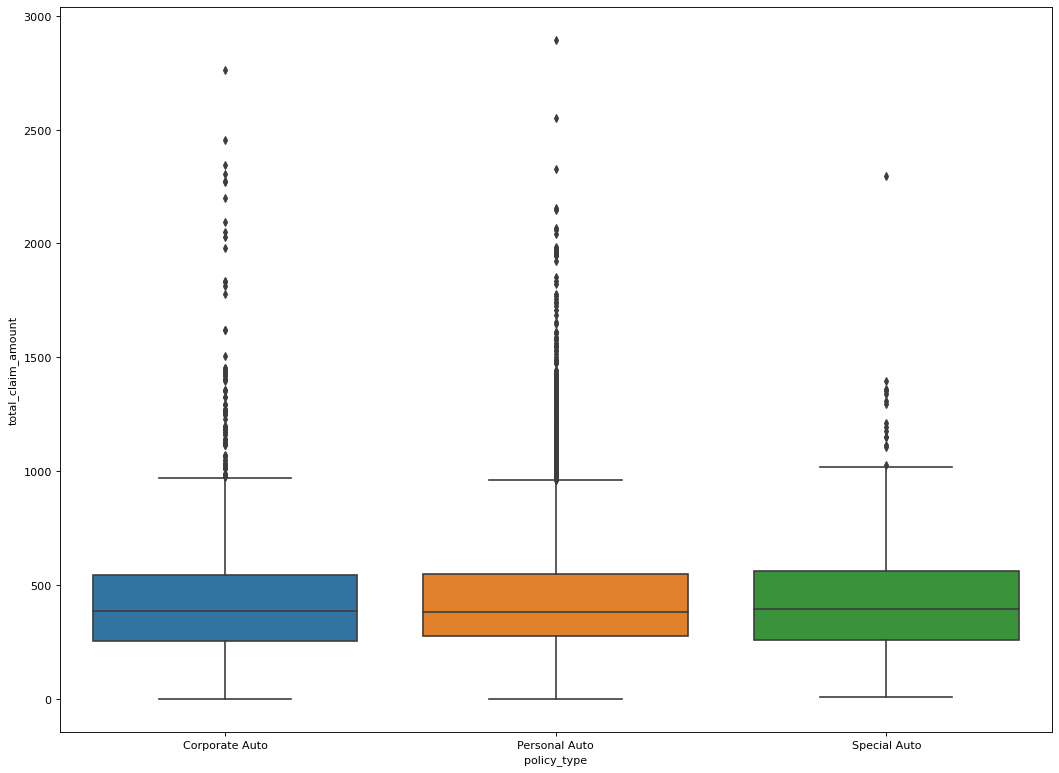

In [48]:
from matplotlib.pyplot import figure
figure(figsize=(16, 12), dpi=80)
sns.boxplot(x="policy_type", y="total_claim_amount", data=customer_df)
plt.show()

We see here that if we except the ourlier, the differences between the three types of policy are not significant. mean, first quartile, iqr range, etc. everything is almost equal for the three types.

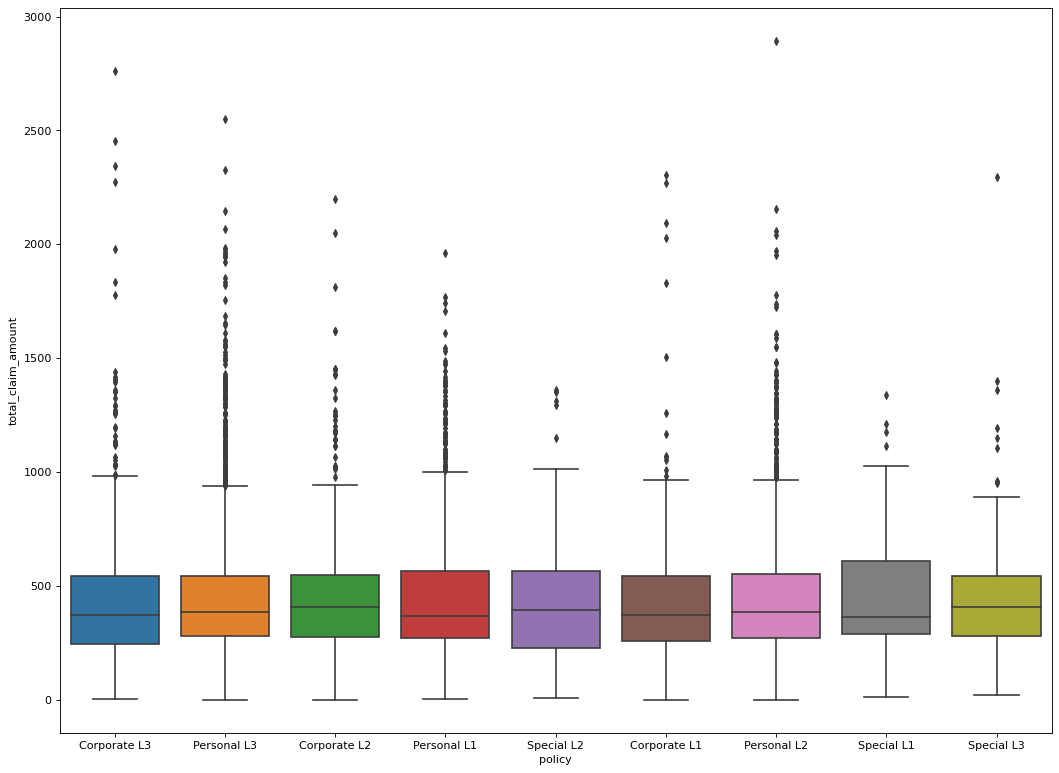

In [49]:
from matplotlib.pyplot import figure
figure(figsize=(16, 12), dpi=80)
sns.boxplot(x="policy", y="total_claim_amount", data=customer_df)
plt.show()

If we look at the detail with L1/L2/L3, we see more differences. This might thus bring more added value to our model. I'll keep this column and drop policy_type.

In [50]:
customer_df = customer_df.drop(['policy_type'], axis=1)

there is not a lot of special policies, so I decide to group them into one subcategory.

In [51]:
customer_df['policy'] = customer_df['policy'].apply(lambda x: 'Special' if 'Special' in x else x)
customer_df['policy'].value_counts()

Personal L3     3426
Personal L2     2122
Personal L1     1240
Corporate L3    1014
Corporate L2     595
Special          378
Corporate L1     359
Name: policy, dtype: int64

## 7. Would you choose to do anything else to clean or wrangle the categorical data? Comment your decisions.

In [52]:
categorical_df = customer_df.select_dtypes(np.object)
categorical_df

C:\Users\ebour\AppData\Local\Temp/ipykernel_20148/697879494.py:1: DeprecationWarning: `np.object` is a deprecated alias for the builtin `object`. To silence this warning, use `object` by itself. Doing this will not modify any behavior and is safe. 
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  categorical_df = customer_df.select_dtypes(np.object)


,state,employment_status,gender,location_code,marital_status,number_of_policies,policy,renew_offer_type,sales_channel,vehicle_class
0,Washington,Employed,F,Suburban,Married,1,Corporate L3,Offer1,Agent,Two-Door Car
1,Arizona,Unemployed,F,Suburban,Single,> 6,Personal L3,Offer3,Agent,Four-Door Car
2,Nevada,Employed,F,Suburban,Married,2,Personal L3,Offer1,Agent,Two-Door Car
3,California,Unemployed,M,Suburban,Married,> 6,Corporate L2,Offer1,Call Center,SUV
4,Washington,Employed,M,Rural,Single,1,Personal L1,Offer1,Agent,Four-Door Car
...,...,...,...,...,...,...,...,...,...,...
9129,California,Employed,M,Urban,Married,2,Personal L1,Offer2,Web,Four-Door Car
9130,California,Employed,F,Suburban,Divorced,1,Corporate L3,Offer1,Branch,Four-Door Car
9131,California,Unemployed,M,Suburban,Single,2,Corporate L2,Offer1,Branch,Four-Door Car
9132,California,Employed,M,Suburban,Married,3,Personal L2,Offer3,Branch,Four-Door Car


In [53]:
# Let's look at the lists of unique values again
for col_name in categorical_df.columns:
    display(categorical_df[col_name].value_counts())

California    3150
Oregon        2601
Arizona       1703
Nevada         882
Washington     798
Name: state, dtype: int64

Employed         5698
Unemployed       2317
Medical Leave     432
Disabled          405
Retired           282
Name: employment_status, dtype: int64

F    4658
M    4476
Name: gender, dtype: int64

Suburban    5779
Rural       1773
Urban       1582
Name: location_code, dtype: int64

Married     5298
Single      2467
Divorced    1369
Name: marital_status, dtype: int64

1      3251
2      2294
> 6    1233
4-6    1188
3      1168
Name: number_of_policies, dtype: int64

Personal L3     3426
Personal L2     2122
Personal L1     1240
Corporate L3    1014
Corporate L2     595
Special          378
Corporate L1     359
Name: policy, dtype: int64

Offer1    3752
Offer2    2926
Offer3    1432
Offer4    1024
Name: renew_offer_type, dtype: int64

Agent          3477
Branch         2567
Call Center    1765
Web            1325
Name: sales_channel, dtype: int64

Four-Door Car    4621
Two-Door Car     1886
SUV              1796
Sports Car        484
Luxury SUV        184
Luxury Car        163
Name: vehicle_class, dtype: int64

By looking at the occurrences inside some columns, I realize that we could probably reduce diversity in the vehicle_class and group some categories

#### Vehicle class

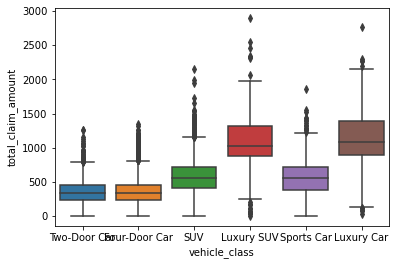

In [54]:
sns.boxplot(x="vehicle_class", y="total_claim_amount", data=customer_df)
plt.show()

By looking at the plot, it makes sense to create three categories : cars, SUV and Luxury as their subcategories contain similar data

In [55]:
def veh_class_cleaning(x):
    if 'Luxury' in x:
        return 'Lux'
    elif 'SUV'in x:
        return 'SUV'
    else:
        return 'Car'

customer_df['vehicle_class'] = customer_df['vehicle_class'].apply(veh_class_cleaning)
customer_df['vehicle_class'].value_counts()

Car    6991
SUV    1796
Lux     347
Name: vehicle_class, dtype: int64

## 8. Compare policy_type and policy. What information is contained in these columns. Can you identify what is important?

Already done in part 6

## 9.0 Check number of unique values in each column, can they be combined in any way to ease encoding? Comment your thoughts and make those changes.

Already done in the previous steps of the lab.

#        LAB 4_3 - FEATURE EXTRACTION

## 1. Open the categoricals variable we created before.

In [56]:
categoricals_df = customer_df.select_dtypes(np.object)
categoricals_df.head()

C:\Users\ebour\AppData\Local\Temp/ipykernel_20148/2224706735.py:1: DeprecationWarning: `np.object` is a deprecated alias for the builtin `object`. To silence this warning, use `object` by itself. Doing this will not modify any behavior and is safe. 
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  categoricals_df = customer_df.select_dtypes(np.object)


,state,employment_status,gender,location_code,marital_status,number_of_policies,policy,renew_offer_type,sales_channel,vehicle_class
0,Washington,Employed,F,Suburban,Married,1,Corporate L3,Offer1,Agent,Car
1,Arizona,Unemployed,F,Suburban,Single,> 6,Personal L3,Offer3,Agent,Car
2,Nevada,Employed,F,Suburban,Married,2,Personal L3,Offer1,Agent,Car
3,California,Unemployed,M,Suburban,Married,> 6,Corporate L2,Offer1,Call Center,SUV
4,Washington,Employed,M,Rural,Single,1,Personal L1,Offer1,Agent,Car


## 2. Plot all the categorical variables with the proper plot. What can you see?

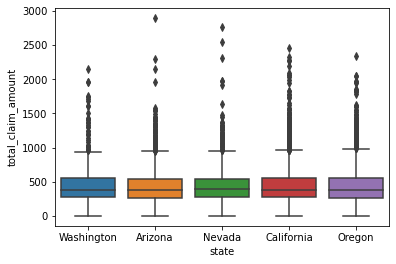

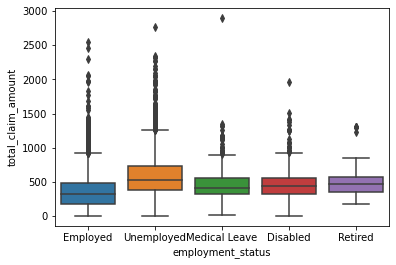

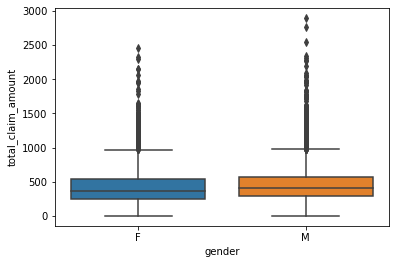

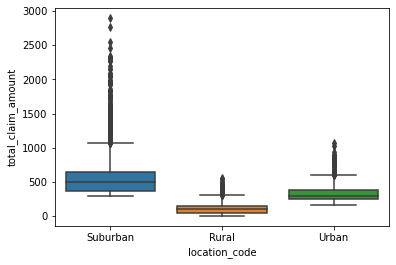

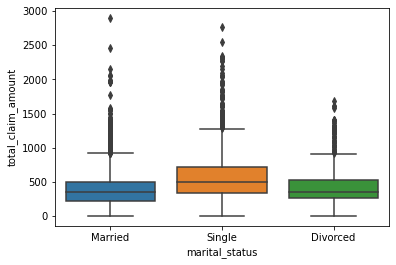

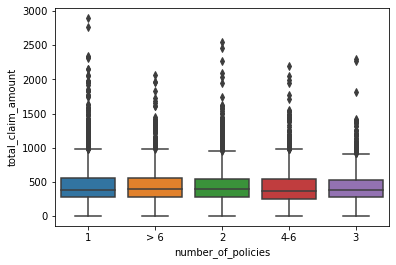

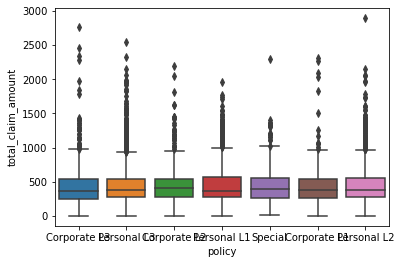

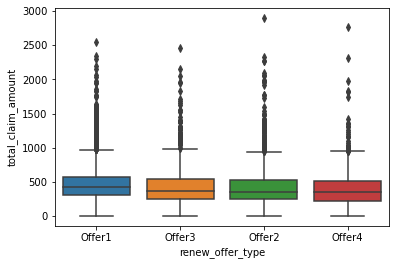

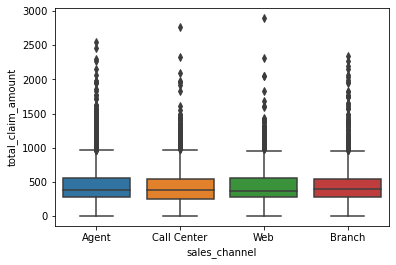

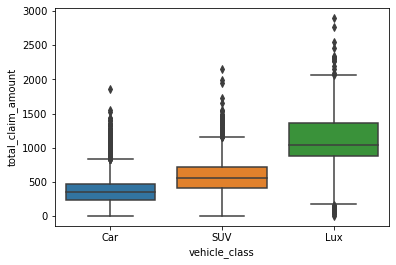

In [57]:
def categorical_box_plot(df):
    for cat in df.columns:
        sns.boxplot(x = cat, y = "total_claim_amount", data = customer_df)
        plt.show()
        
categorical_box_plot(categorical_df)

We see that for most of the categoricals, all categories show very similar claim amounts.
The one that stick out and actually show "variable" claim amounts are :

- vehicle class
- marital status (single versus married and divorced that are similar)
- location code
- gender (more outliers for men)
- employment status (even if less significant)

## 3. There might be some columns that seem to be redundant, check their values to be sure. What should we do with them?

In [58]:
customer_df.dtypes

state                                    object
customer_lifetime_value                 float64
response                                   bool
coverage                                  int64
education                                 int64
effective_to_date                datetime64[ns]
employment_status                        object
gender                                   object
income                                    int64
location_code                            object
marital_status                           object
monthly_premium_auto                      int64
months_since_last_claim                   int64
months_since_policy_inception             int64
number_of_open_complaints                 int64
number_of_policies                       object
policy                                   object
renew_offer_type                         object
sales_channel                            object
total_claim_amount                      float64
vehicle_class                           

I can drop the columns of the data we have categorized : income, months since last claim, months since inception and monthly premium.

In [59]:
customer_df = customer_df.drop(['income', 'months_since_last_claim', 'months_since_policy_inception', 'number_of_open_complaints', 'monthly_premium_auto'], axis=1)

I can also drop the temporary columns used during the cleaning process

In [60]:
customer_df = customer_df.drop(['premium_category', 'policy_check'], axis=1)

In [61]:
customer_df.dtypes

state                                   object
customer_lifetime_value                float64
response                                  bool
coverage                                 int64
education                                int64
effective_to_date               datetime64[ns]
employment_status                       object
gender                                  object
location_code                           object
marital_status                          object
number_of_policies                      object
policy                                  object
renew_offer_type                        object
sales_channel                           object
total_claim_amount                     float64
vehicle_class                           object
vehicle_size                             int64
years_since_last_claim                   int64
years_since_policy_inception             int64
open_complaints                           bool
income_category_userdef               category
premium_categ

In [62]:
numerical_df = customer_df._get_numeric_data()

In [63]:
numerical_df

,customer_lifetime_value,response,coverage,education,total_claim_amount,vehicle_size,years_since_last_claim,years_since_policy_inception,open_complaints
0,2763.519279,False,1,3,384.811147,2,2,2,False
1,6979.535903,False,2,3,1131.464935,2,1,4,False
2,12887.431650,False,3,3,566.472247,2,1,4,False
3,7645.861827,False,1,3,529.881344,2,1,6,False
4,2813.692575,False,1,3,138.130879,2,1,4,False
...,...,...,...,...,...,...,...,...,...
9129,23405.987980,False,1,3,198.234764,2,1,8,False
9130,3096.511217,True,2,2,379.200000,2,1,4,False
9131,8163.890428,False,2,3,790.784983,2,0,4,True
9132,7524.442436,False,2,2,691.200000,3,2,2,False


I do not think that there is any redundant information anymore.

## 4. Plot time variable. Can you extract something from it?

In [64]:
import matplotlib.pyplot
import matplotlib.dates

from datetime import datetime

x_values = customer_df['effective_to_date']
y_values = customer_df['total_claim_amount']

dates = matplotlib.dates.date2num(x_values)

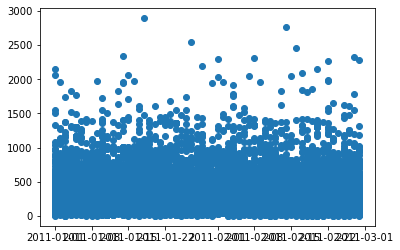

In [65]:
matplotlib.pyplot.plot_date(dates, y_values)

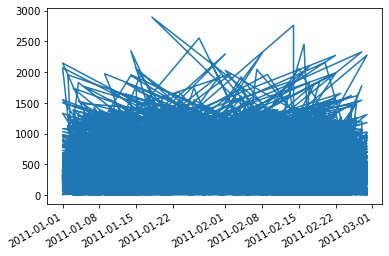

In [66]:
# plot
plt.plot(x_values,y_values)
# beautify the x-labels
plt.gcf().autofmt_xdate()

plt.show()

In [78]:
# This is impossible to use. I should have looked at the data first...
customer_df['effective_to_date'].describe()

C:\Users\ebour\AppData\Local\Temp/ipykernel_20148/1211005787.py:1: FutureWarning: Treating datetime data as categorical rather than numeric in `.describe` is deprecated and will be removed in a future version of pandas. Specify `datetime_is_numeric=True` to silence this warning and adopt the future behavior now.
  customer_df['effective_to_date'].describe()


count                    9134
unique                     59
top       2011-01-10 00:00:00
freq                      195
first     2011-01-01 00:00:00
last      2011-02-28 00:00:00
Name: effective_to_date, dtype: object

I need to group by the data by date.

In [80]:
date_df = customer_df[['effective_to_date', 'total_claim_amount']]
date_df_sum = date_df.groupby('effective_to_date', as_index=False).agg({'total_claim_amount':sum})
date_df_mean = date_df.groupby('effective_to_date', as_index=False).agg({'total_claim_amount':np.mean})

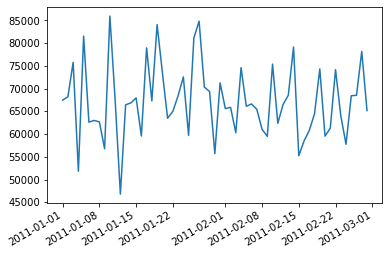

In [81]:
x_values = date_df_sum['effective_to_date']
y_values = date_df_sum['total_claim_amount']
plt.plot(x_values,y_values)
plt.gcf().autofmt_xdate()     # code found here https://stackoverflow.com/questions/1574088/plotting-time-in-python-with-matplotlib/16428019
plt.show()

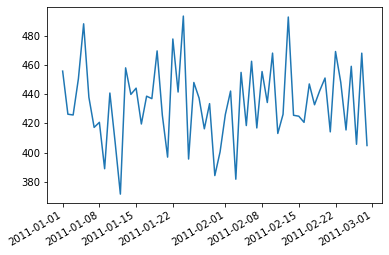

In [82]:
x_values = date_df_mean['effective_to_date']
y_values = date_df_mean['total_claim_amount']
plt.plot(x_values,y_values)
plt.gcf().autofmt_xdate()
plt.show()

If we aggregate the data with a sum or with a mean, we obtain similar results that do not say much at a date level.
Maybe that would mean that the 'effective_to_date' info has no impact on the total_claim_amount target.

Let's try to group the data further and look at it per month.

In [85]:
date_df_sum['month'] = pd.DatetimeIndex(date_df_sum['effective_to_date']).month
date_df_mean['month'] = pd.DatetimeIndex(date_df_mean['effective_to_date']).month

In [86]:
date_df_sum_month = date_df_sum.groupby('month', as_index=False).agg({'total_claim_amount':sum})
date_df_mean_month = date_df_mean.groupby('month', as_index=False).agg({'total_claim_amount':np.mean})

In [87]:
date_df_sum_month

,month,total_claim_amount
0,1,2.117143e+06
1,2,1.847824e+06


In [88]:
date_df_mean_month

,month,total_claim_amount
0,1,431.948821
1,2,436.585620


We see that for the two available months of 'effective to date' (whatever that means), the sum of claim amount are different, but that is only because the month of January has more days than February, as the average claim amounts are almost equal. This confirms that the date does not seem to have any impact on the claim amount.